# Detectability limit: the October 2024 Valencia DANA

A worked example with the [`euroflood`](https://github.com/cisgroup/euroflood) package,
reproducing Section S1.6 (main text Section 7.4, Fig. 8) of the EuroFlood paper. Unlike the
other notebooks in this series, this one is an honest look at a **limitation of the source
archive**, not a package failure. For a rapid, flashy flood, a satellite record built on
Sentinel-1 revisits can capture only a fraction of what happened, and it is important to show
where the archive falls short as clearly as where it succeeds.

## The event

On **29 October 2024** a DANA (a cut-off upper-level depression) brought extreme convective
rainfall to the Valencia region, locally up to **772 mm in 24 hours**. It was one of Europe's
deadliest recent floods. HANZE, an independent documentary record of European flood impacts,
documents **236 fatalities**, **36,803 people affected**, and **226 km<sup>2</sup>** of
inundation across four NUTS level 3 provinces. This is a rapid pluvial and flash-flood regime,
exactly the kind that can develop and drain between successive satellite acquisitions, so it is
a hard test of what the archive can see.

## The archive and the index

The observations come from the **CEMS-EFAS satellite-derived flood-depth maps** (the only open,
continental record of observed flood depth, reconstructed from Sentinel-1), which `euroflood`
serves through an **inverted raster index**. Access is two-stage: **Discover** with `floods(...)`
returning a `FloodFrame` (a `geopandas.GeoDataFrame`), then **Extract** native 20 m depth with
`download()`. For this event we expect the archive to be *incomplete*, and the point of the
notebook is to quantify by how much, honestly.

> Runs against `euroflood >= 0.2.0` with the `viz` extra, querying the published index
> (needs network on first use, or a locally mirrored index).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown

import euroflood as ef

import _support as S

## The documentary record

Before looking at what the archive detected, we read what was *documented*. HANZE (the
Historical Analysis of Natural Hazards in Europe, committed with the paper) gives an
independent reference: the documented flood area, the impacts, and the four affected provinces.

In [2]:
hanze = pd.read_csv(S.DATA / "hanze" / "HANZE_events_v3_0_1b.csv")
region_col = "Regions affected (NUTS 3)"
dana = hanze[
    (hanze["Year"] == 2024)
    & (hanze[region_col].astype(str).str.contains("ES523"))
    & (hanze["Start date"].astype(str).str.startswith("2024-10"))
].iloc[0]

documented_km2 = float(dana["Area affected"])
provinces_codes = dana[region_col].split(";")
print(f"documented flood area: {documented_km2:.0f} km2")
print(f"fatalities: {int(dana['Fatalities'])} · people affected: {int(dana['Persons affected']):,}")
print(f"cause: {dana['Cause']}")
print(f"provinces (NUTS-3): {provinces_codes} · window {dana['Start date']} to {dana['End date']}")

documented flood area: 226 km2
fatalities: 236 · people affected: 36,803
cause: Heavy rainfall up to 772 mm in 24 h
provinces (NUTS-3): ['ES421', 'ES423', 'ES523', 'ES617'] · window 2024-10-27 to 2024-11-04


## 1. Discover

One query over a box covering the documented provinces returns the archived clusters. The date
filter acts on each cluster's *start* date, so neighbouring episodes fall outside the window;
the archive holds a single Sentinel-1 acquisition associated with the Valencia flood.

In [3]:
cat = ef.floods(bbox=(-5.7, 36.0, 1.2, 41.2), start="2024-10-28", end="2024-11-15")
cat[["event_id", "date", "end_date", "area_km2"]]

,event_id,date,end_date,area_km2
27,2801412471,2024-10-28,2024-11-11,2.623
110,3396208066,2024-11-04,2024-11-18,81.331


Two clusters are returned: the Valencia capture (start 4 November) and a geographically separate
south-west Spain file. `footprints=True` draws each event's extent on the grey basemap (the
query window is large, so we map the footprints rather than a continental recurrence grid).

In [4]:
cat.explore(footprints=True, tiles="grayscale")

## 2. The single capture

The Valencia acquisition is dated **4 November**, six days after the rainfall peak. We download
the native 20 m depth and read it as a `DepthRaster`. The detected water is shallow and
concentrated south of Valencia around the **l'Albufera** lagoon and its rice paddies, not in the
Horta Sud streets (Paiporta, Catarroja, Torrent) worst hit during the event.

In [5]:
dl = cat.download(str(S.ROOT / "out" / "dana_notebook"))
full_file_km2 = float(dl.stats()["flooded_area_km2"].sum())
print(f"full event-file detected water (both clusters): {full_file_km2:.1f} km2")

valencia = dl.nlargest(1, "area_km2")
ef.open_depth(valencia["path"].iloc[0]).explore(tiles="grayscale", vmax=1.0)

Output()

full event-file detected water (both clusters): 58.7 km2


## 3. The same ground: within the documented provinces

To compare like with like, we restrict the detected water to the four documented provinces. We
build their boundary from a GISCO NUTS level 3 union and query with `shape="exact"`; the
download is cropped to that boundary, so `.stats()` reports the in-province detected area
directly (public API, no manual raster masking).

In [6]:
nuts = gpd.read_file(S.DATA / "gisco" / "nuts_20m_2024.geojson")
provinces = nuts[(nuts["LEVL_CODE"] == 3) & (nuts["NUTS_ID"].isin(provinces_codes))].dissolve()

in_region = ef.floods(provinces, start="2024-10-28", end="2024-11-15", shape="exact")
region_stats = in_region.download(str(S.ROOT / "out" / "dana_notebook")).stats()
captured_km2 = float(region_stats["flooded_area_km2"].sum())
fraction = captured_km2 / documented_km2
print(f"detected within the documented provinces: {captured_km2:.1f} km2")
print(f"that is {fraction:.0%} of the documented {documented_km2:.0f} km2")

Output()

detected within the documented provinces: 35.2 km2
that is 16% of the documented 226 km2


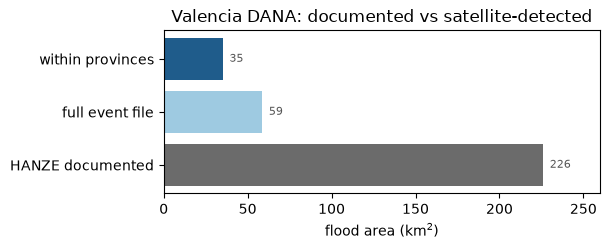

In [7]:
# Documented against captured, the detectability gap at a glance.
bars = {
    "HANZE documented": documented_km2,
    "full event file": full_file_km2,
    "within provinces": captured_km2,
}
fig, ax = plt.subplots(figsize=(6.2, 2.6))
ax.barh(list(bars), list(bars.values()), color=["#6b6b6b", "#9ecae1", "#1f5c8b"])
ax.set_xlabel("flood area (km$^2$)")
ax.set_title("Valencia DANA: documented vs satellite-detected")
for i, v in enumerate(bars.values()):
    ax.text(v + 4, i, f"{v:,.0f}", va="center", fontsize=8, color="#555555")
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

In [8]:
# Key figures, computed from the cells above.
Markdown(
    f"### Key figures\n"
    f"| | |\n|---|---|\n"
    f"| **Documented flood area (HANZE)** | **{documented_km2:.0f} km²** |\n"
    f"| **Detected within the documented provinces** | **{captured_km2:.1f} km²** ({fraction:.0%}) |\n"
    f"| **Full event-file detected water** | **{full_file_km2:.1f} km²** |\n"
    f"| **Capture date / lag after peak** | **4 Nov 2024 / 6 days** |\n"
    f"| **Impact (HANZE)** | **{int(dana['Fatalities'])} fatalities, "
    f"{int(dana['Persons affected']):,} affected** |\n"
)

### Key figures
| | |
|---|---|
| **Documented flood area (HANZE)** | **226 km²** |
| **Detected within the documented provinces** | **35.2 km²** (16%) |
| **Full event-file detected water** | **58.7 km²** |
| **Capture date / lag after peak** | **4 Nov 2024 / 6 days** |
| **Impact (HANZE)** | **236 fatalities, 36,803 affected** |


## The published figure

The paper's three-panel Fig. 8 (the single capture with its shallow-depth histogram, the
building-scale detail in the Horta Sud, and the documented-vs-captured summary with the event
timeline) is assembled by the paper's figure script, shown here for comparison.

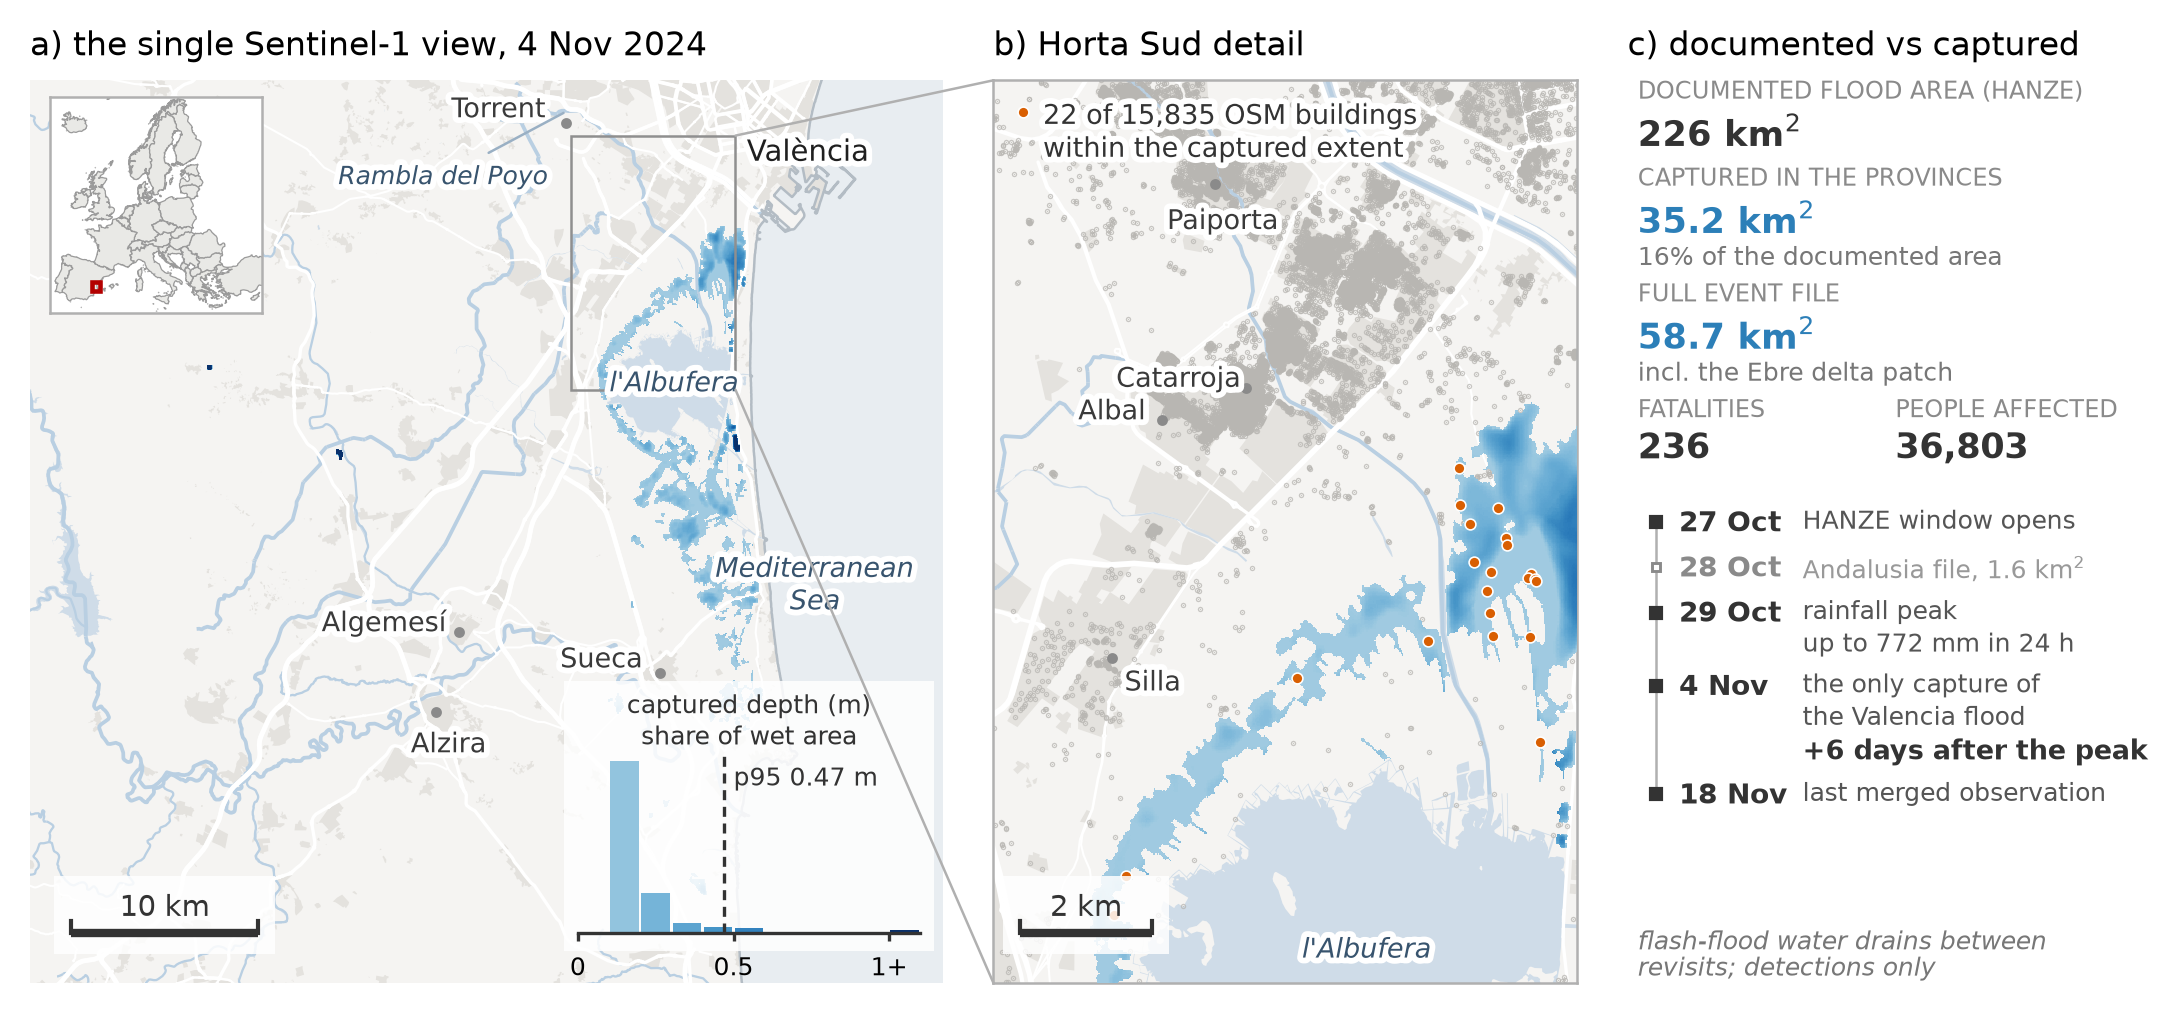

In [9]:
S.published_figure("dana")

## Interpretation

The archive captures roughly **16%** of the documented flood area, and that figure needs care:

1. **It is an order-of-magnitude indication of representation, not a detection rate.** The two
   numbers measure different things: delayed *standing* water seen on 4 November versus the wider
   area *documented* as affected over the whole event.
2. **A small footprint does not mean a small flood.** This was a catastrophic event; the archive
   simply did not observe most of it, because rapid pluvial and flash inundation can drain
   between Sentinel-1 revisits, leaving only shallow residual water on a delayed acquisition.
3. **Use the right tool for the regime.** For fast, flashy events, the archive should be
   supplemented with documentary records (as here) or rapid-mapping products; its strength is
   the broad, persistent flooding of large rivers, not flash floods.

This is a limitation of the *source archive*, faithfully surfaced by the query interface, not a
limitation of the index or the library.

## References and reuse

This notebook reproduces the Valencia DANA case study (Supplementary Material, Section S1.6;
main text Section 7.4, Fig. 8) of:

> J. Hackl (2026). *EuroFlood: a Python library and queryable index for the CEMS
> satellite-derived flood-depth archive of Europe.*